<a href="https://colab.research.google.com/github/Pranayshukla0610/deep-learning/blob/main/Deep_Learning_NLP_On_Google_Play_Store_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('punkt_path')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading punkt_path: Package 'punkt_path' not found
[nltk_data]     in index


False

In [ ]:
df = pd.read_csv('/content/reviews.csv.zip')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


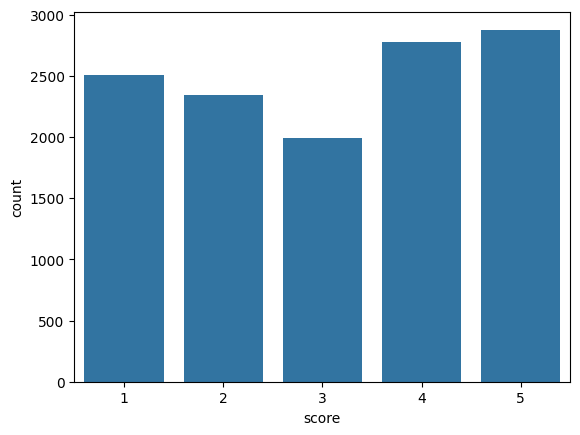

In [ ]:
sns.countplot(x=df['score'])
plt.show()

In [ ]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'<.*?>','',text)
  text = re.sub(r'a-zA-Z\s','',text)
  text = re.sub(r'http\S+','',text)
  return text

df['Clean_text'] = df['reviewId'].apply(clean_text)

In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId,Clean_text
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo,gp:aoqptoehzuqsqqwnakrgv-9abydajfub0wugpgh-sg-...
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo,gp:aoqptoh0wp4iqkbz2lrdnmfy_ymppcvrv3dieu9kgm3...
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo,gp:aoqptoemckjb8iq1p-r9dpwnsyada5bkpwtf32z1azu...
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo,gp:aoqptogfruwukgycpje8kszj3uwhn6tu_fd4glvfy9z...
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo,gp:aoqptohls7dw8wmdfztkhwxuqfkdnqtkhmo6pt9jhze...


In [ ]:
df = df[['content','score']]
df.dropna(inplace=True)
df = df[df['content']!=""]

In [ ]:
df.head()

,content,score
0,I cannot open the app anymore,1
1,I have been begging for a refund from this app...,1
2,Very costly for the premium version (approx In...,1
3,"Used to keep me organized, but all the 2020 UP...",1
4,Dan Birthday Oct 28,1


In [ ]:
def map_sentiment(score):
  if score <= 2:
    return 0
  elif score == 3:
    return 1
  else:
    return 2

df['label'] = df['score'].apply(map_sentiment)

In [ ]:
df.head()

,content,score,label
0,I cannot open the app anymore,1,0
1,I have been begging for a refund from this app...,1,0
2,Very costly for the premium version (approx In...,1,0
3,"Used to keep me organized, but all the 2020 UP...",1,0
4,Dan Birthday Oct 28,1,0


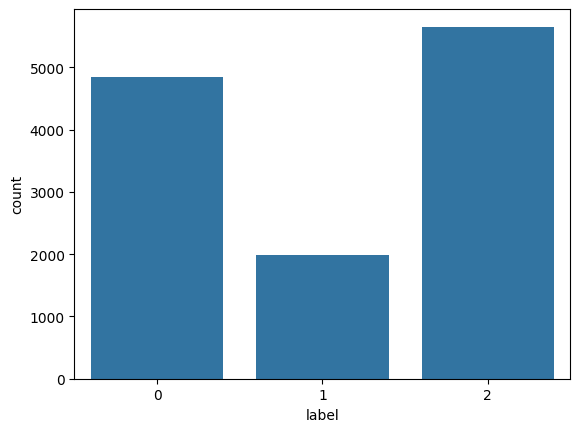

In [ ]:
sns.countplot(x=df['label'])
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
  text = text.lower()
  text = re.sub(r'http\S+','',text)
  text = re.sub(r'[a-zA-Z]','',text)

  tokens = word_tokenize(text)
  tokens = [w for w in tokens if w not in stop_words]
  tokens = [lemmatizer.lemmatize(w) for w in tokens]

  return " ".join(tokens)

df['clean_text'] = df['content'].apply(preprocess)

In [ ]:
from collections import Counter
all_words = " ".join(df['clean_text']).split()
freq = Counter(all_words).most_common(20)

freq_df = pd.DataFrame(freq,columns=['Word','Frequency'])
freq_df

,Word,Frequency
0,.,20386
1,",",9758
2,',8141
3,!,3182
4,?,1244
5,-,1125
6,),1071
7,``,1032
8,(,992
9,:,906


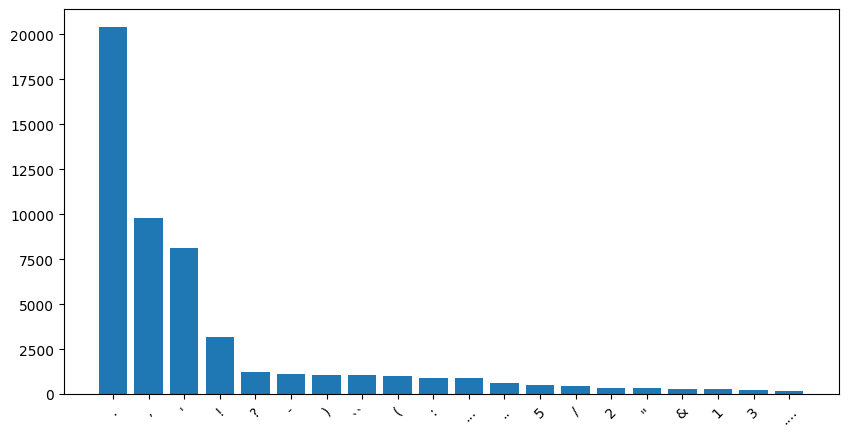

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(freq_df['Word'],freq_df['Frequency'])
plt.xticks(rotation=45)
plt.show()

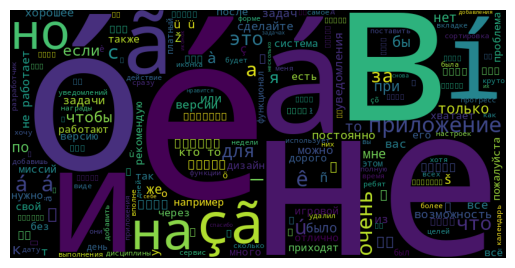

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400).generate(" ".join(all_words))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [ ]:
fig = px.scatter_3d(
    freq_df,
    x='Word',
    y='Frequency',
    z='Frequency'
)

In [ ]:
fig.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=15000)
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(sequences, maxlen=200)

y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(
    X_train.reshape(len(X_train),-1),y_train)

X_train_res = X_train_res.reshape(-1,200)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(15000,128,input_length=200),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',

)

model_lstm.fit(X_train_res,y_train_res,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



426/426 ━━━━━━━━━━━━━━━━━━━━ 183s 424ms/step - loss: 1.0816 - val_loss: 1.0638
Epoch 2/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 171s 402ms/step - loss: 1.0609 - val_loss: 1.0878
Epoch 3/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 169s 396ms/step - loss: 1.0424 - val_loss: 1.0570
Epoch 4/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 163s 382ms/step - loss: 1.0299 - val_loss: 1.0819
Epoch 5/5
426/426 ━━━━━━━━━━━━━━━━━━━━ 165s 386ms/step - loss: 1.0201 - val_loss: 1.0903


In [ ]:
from tensorflow.keras.layers import Bidirectional
model_bilstm = Sequential([
    Embedding(15000,128,input_length=200),
    Bidirectional(LSTM(128)),
    Dense(3,activation='softmax')
])

In [ ]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D
model_cnn = Sequential([
    Embedding(15000,128,input_length=200),
    Conv1D(128,5,activation='relu'),
    GlobalMaxPooling1D(),
    Dense(3,activation='softmax')
])

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step


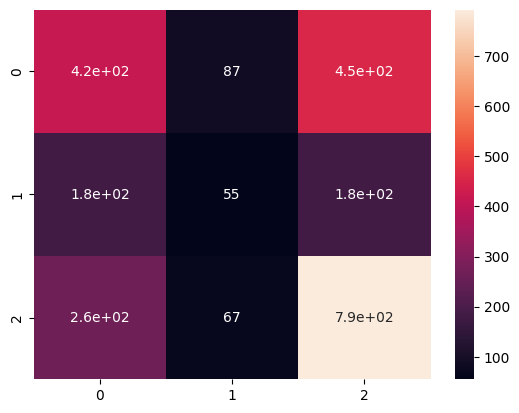

In [ ]:
from sklearn.metrics import confusion_matrix

pred = model_lstm.predict(X_test)
pred_classes = np.argmax(pred,axis=1)

cm = confusion_matrix(y_test,pred_classes)
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

model_emb = SentenceTransformer('all-MiniLM-L6-v2')
emb = model_emb.encode(df['clean_text'][:2000])

pca = PCA(n_components=3)
emb_3d = pca.fit_transform(emb)

fig = px.scatter_3d(
    x=emb_3d[:,0],
    y=emb_3d[:,1],
    z=emb_3d[:,2],
    color=df['label'][:2000]
)
fig.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import transformers
print(transformers.__version__)

5.1.0


In [ ]:
!pip uninstall -y transformers
!pip install transformers tensorflow

Found existing installation: transformers 5.1.0
Uninstalling transformers-5.1.0:
  Successfully uninstalled transformers-5.1.0
  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
Using cached transformers-5.1.0-py3-none-any.whl (10.3 MB)


In [ ]:
import sys
print(sys.version)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip uninstall -y transformers tensorflow keras
!pip install transformers[tf] tensorflow

Found existing installation: transformers 5.1.0
Uninstalling transformers-5.1.0:
  Successfully uninstalled transformers-5.1.0
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached keras-3.13.2-py3-none-any.whl (1.5 MB)
Using cached transformers-5.1.0-py3-none-any.whl (10.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-d

In [ ]:
!pip install transformers torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

print("Model loaded successfully!")


  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
Using cached transformers-5.1.0-py3-none-any.whl (10.3 MB)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [ ]:
import joblib

joblib.dump(tokenizer,"tokenizer.pkl")
model_lstm.save("google_review_model.h5")